## Loading Required Modules

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier, MLPRegressor

import tensorflow as tf
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import Dense

# Disable warnings
import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn

# Load data
odf = pd.read_csv("Hotel_Bookings_Clean.csv")   # We make an original version of the dataset for later usage
odf.pop("Unnamed: 0")
df = odf.copy(True)
df = df[df["adr"] <= 1000]

2026-06-12 11:45:50.129669: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# 1. Multilayer Perceptron

## 1.1 MLP For Binary Classifcation
#### We are trying to predict cacnelaction using this method.

### 1.1.B.1 Training & Optimization
#### First we are going to analysie the effect of different optimizers.

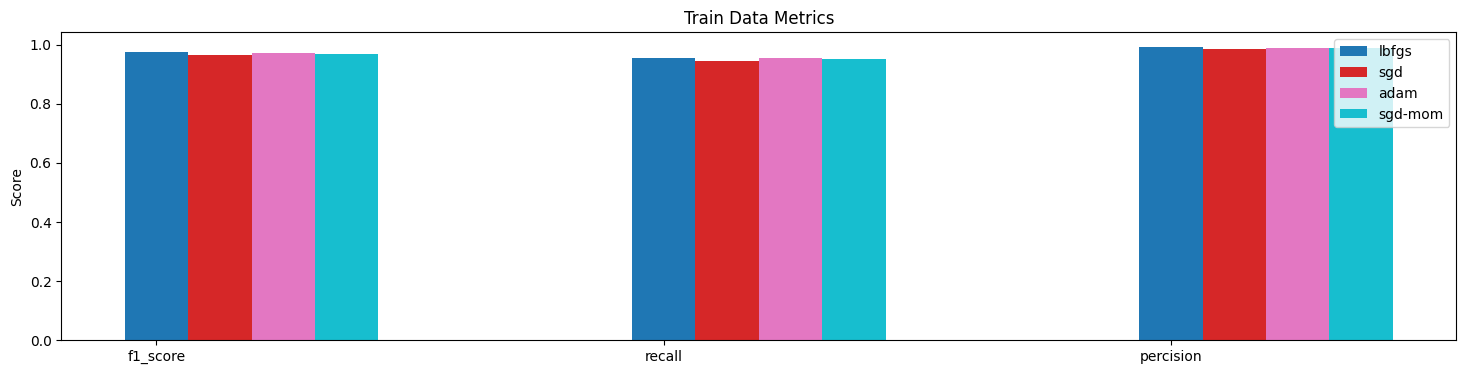

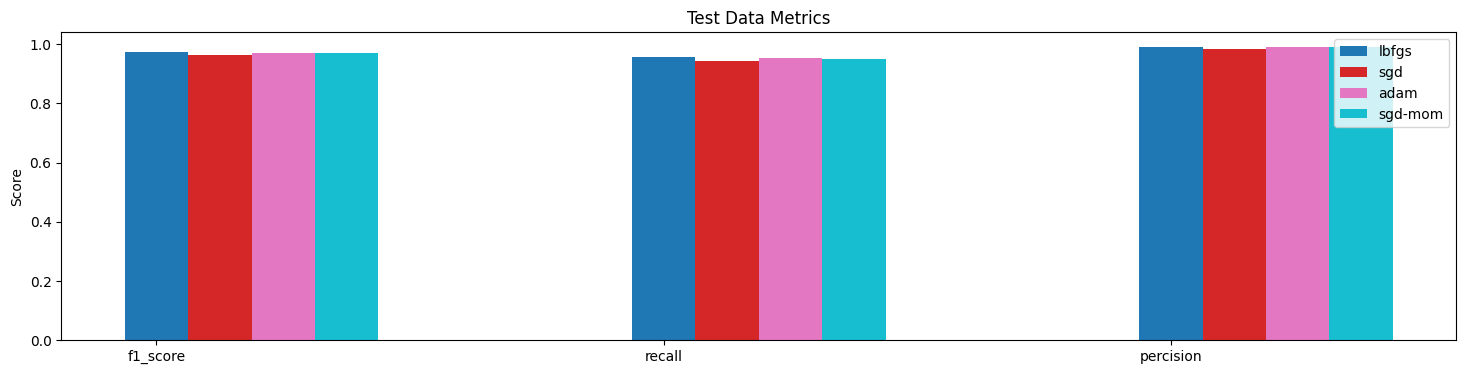

In [ ]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
solvers = ['lbfgs', 'sgd', 'adam', 'sgd+mome']
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, solver in enumerate(solvers):

    if solver == 'sgd-mom':
        model = MLPClassifier(solver='sgd', alpha=1e-5,hidden_layer_sizes=(5, 2),max_iter=500, momentum=.9)
    else:
        model = MLPClassifier(solver=solver, alpha=1e-5,hidden_layer_sizes=(5, 2),max_iter=500)
    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "solver": solver,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "solver": solver,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["solver"] if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["solver"] if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### It seems the solver does not make a significant difference in the results. Such conclusion means the data is not an edge case where one solver works really well nor fails entirely.

#### Next we explore the effect of learning rate variation, with a constant learning rate scheduling.

rate: 0.8
rate: 0.01
rate: 1e-05


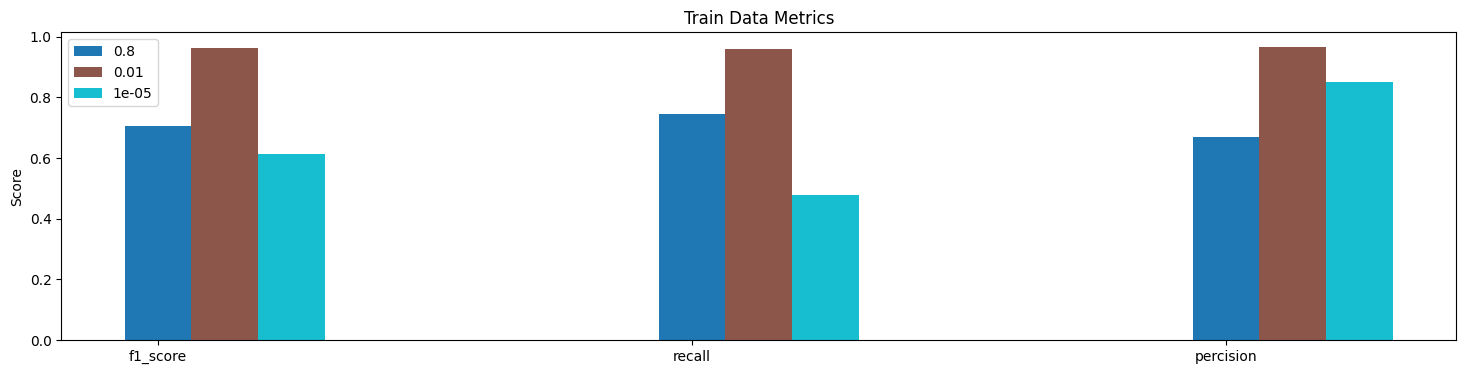

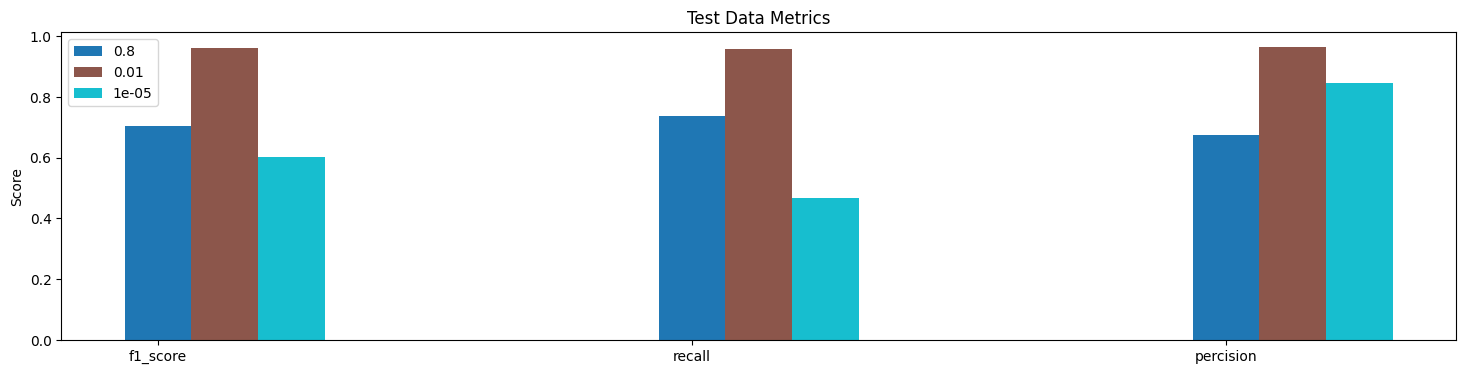

In [ ]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
rates = [8e-1, 1e-2, 1e-5]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, rate in enumerate(rates):

    model = MLPClassifier(solver='sgd',learning_rate="constant", learning_rate_init=rate, alpha=1e-5,hidden_layer_sizes=(5, 2),max_iter=500, momentum=.9)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "rate": rate,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "rate": rate,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })

    print(f"rate: {rate}")


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"rate = {entry["rate"]}" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"rate = {entry["rate"]}" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### As it is shown, a learning rate too large or too small results in worse scores.

#### Next we analyize the effect of learning rate scheduling.

rate: 1e-05
rate: 1e-05
rate: 1e-05


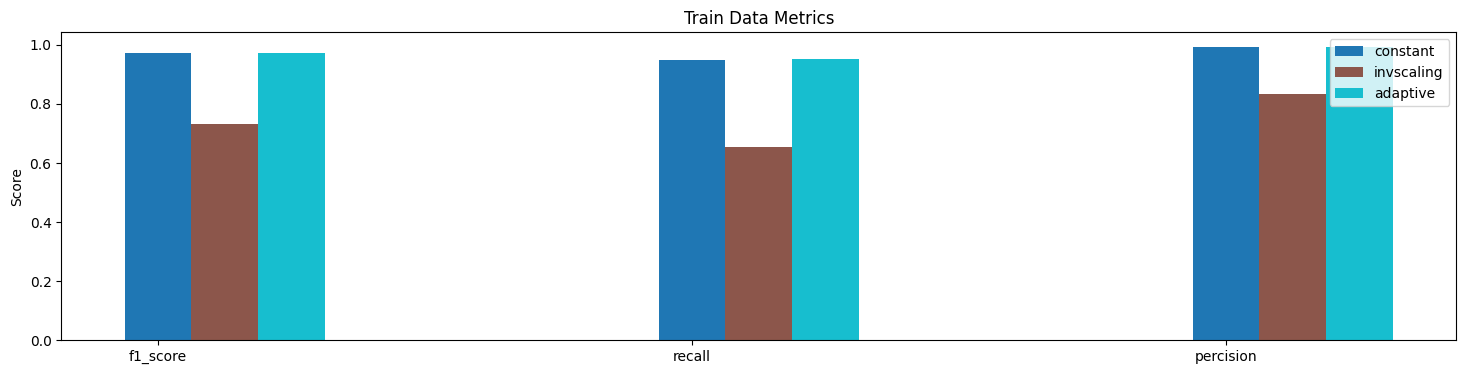

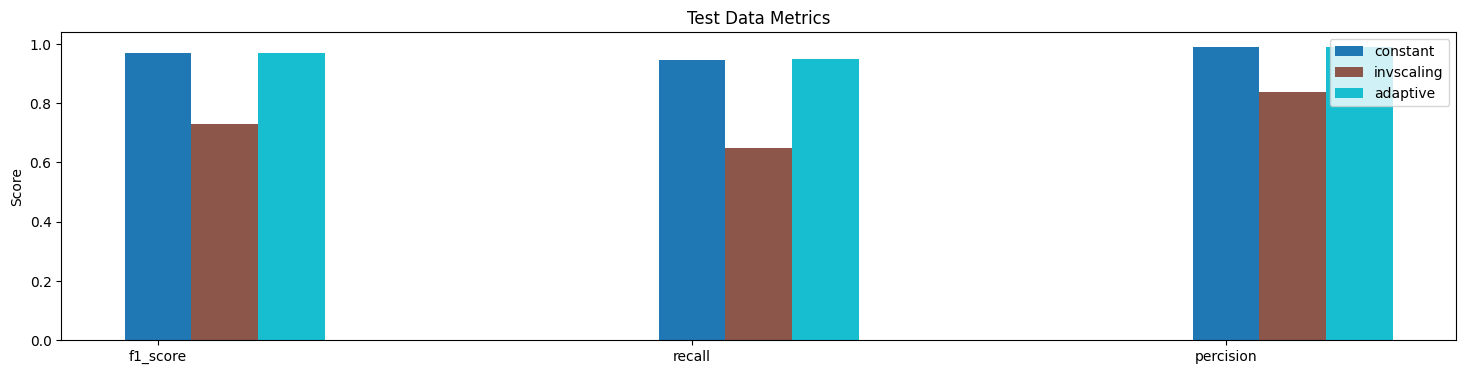

In [ ]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
schedules = ["constant", "invscaling", "adaptive"]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, sch in enumerate(schedules):

    model = MLPClassifier(solver='sgd',learning_rate=sch, learning_rate_init=0.01, alpha=1e-5,hidden_layer_sizes=(5, 2),max_iter=500, momentum=.9)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "schedule": sch,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "schedule": sch,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["schedule"] if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["schedule"] if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### Looking at the results, the inverse scaling system is working poorly. The reason is most likely that the learning rate is decaying too quickly, before the model is able to learn properly. On the other side, constant and adaptive schedules, allow for stable updates in the model as much it's needed.

#### Next we are going to analyize the effect of Batch size.

[772, 154, 23]


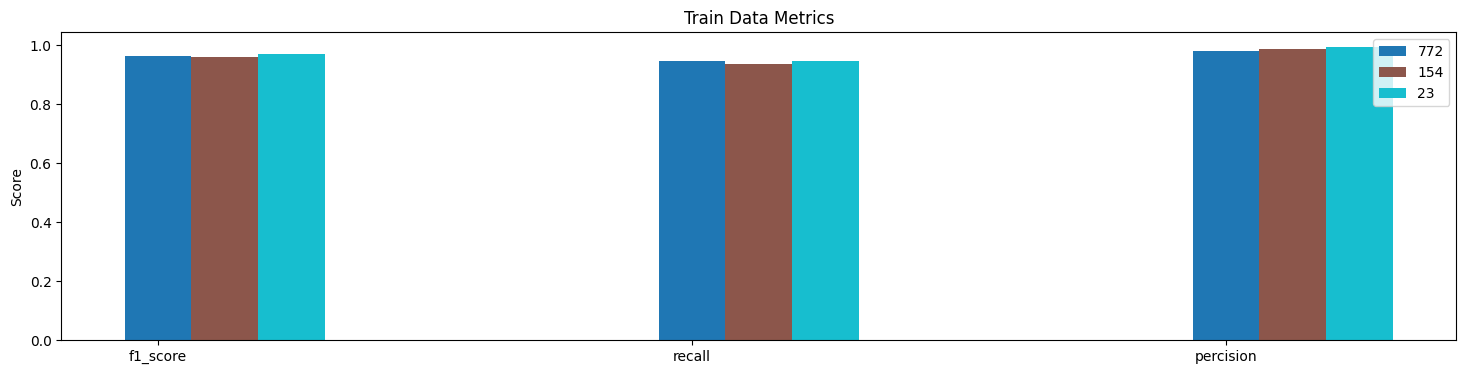

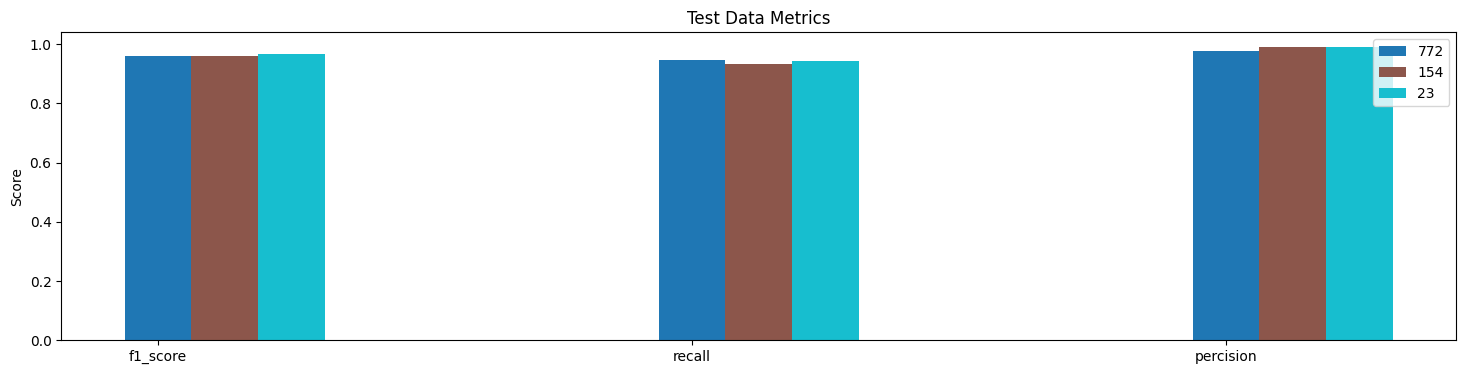

In [ ]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
num_samples = X_train.shape[0]
batch_size = [ 
    int(1e-2 * num_samples), 
    int(2e-3 * num_samples), 
    int(3e-4 * num_samples)
    ]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, batch in enumerate(batch_size):

    model = MLPClassifier(solver='adam',learning_rate="constant", learning_rate_init=0.01, alpha=1e-5,hidden_layer_sizes=(5, 2),max_iter=500, batch_size=batch)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "batch": batch,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "batch": batch,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"{entry["batch"]} batches" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"{entry["batch"]} batches" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### The charts show that batch size virtually does not matter. This means that data is consistent, there aren't huge fluctuations in the vectors and the trend is consistent among the data.

#### The next factor is Early stopping.

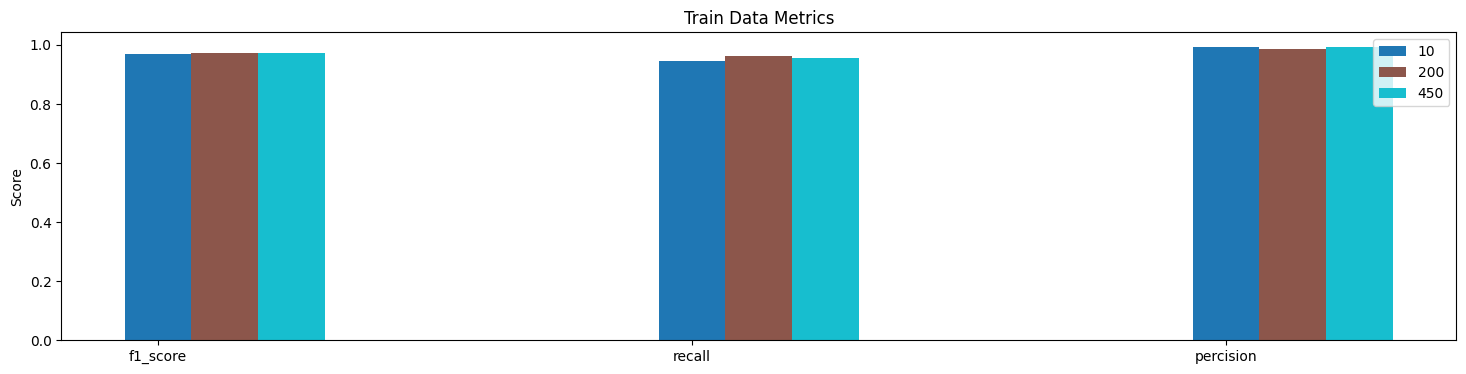

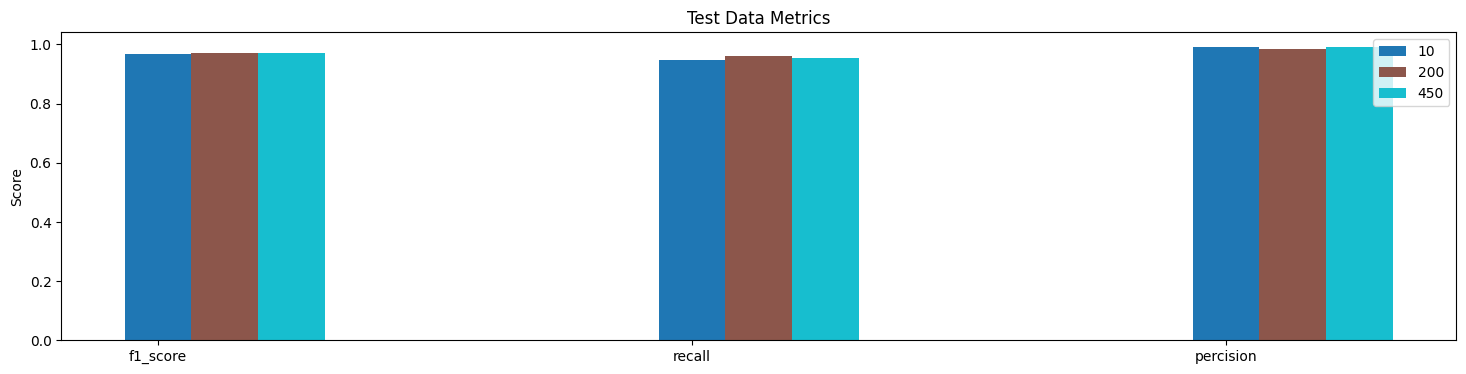

In [ ]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
num_samples = X_train.shape[0]
num_iterations = [10, 200, 450]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, itnc in enumerate(num_iterations):

    model = MLPClassifier(solver='adam', early_stopping=True, validation_fraction=0.1, n_iter_no_change=itnc, learning_rate="constant", learning_rate_init=0.01, alpha=1e-5, hidden_layer_sizes=(5, 2), max_iter=500)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "iterations": itnc,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "iterations": itnc,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"{entry["iterations"]} iterations" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"{entry["iterations"]} iterations" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### Early stopping does not make a meanningful difference in the results as it is shown above. This was actually expected, for the same reason batch size wasn't a game changing factor.

#### Now the number of epochs.

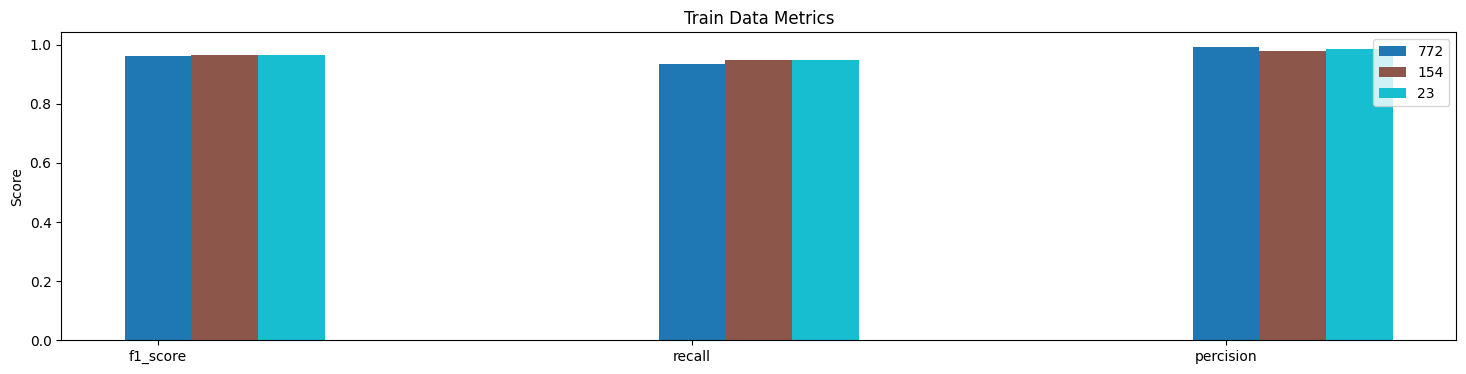

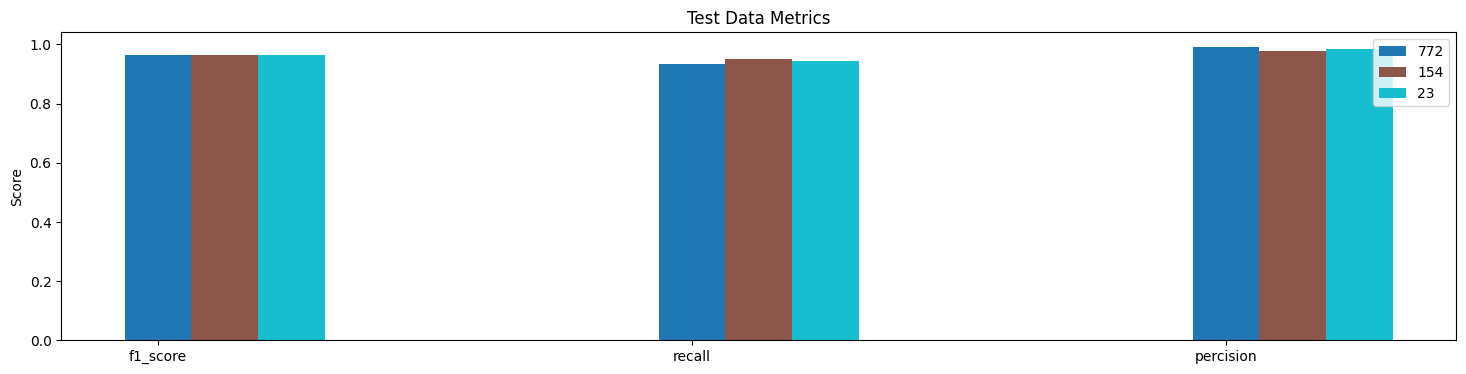

In [ ]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
num_samples = X_train.shape[0]
epochs = [80,350,700]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, epoch in enumerate(batch_size):

    model = MLPClassifier(solver='adam',learning_rate="constant", learning_rate_init=0.01, alpha=1e-5,hidden_layer_sizes=(5, 2),max_iter=epoch)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "epoch": epoch,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "epoch": epoch,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["epoch"] if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.xlabel("Number Of Epochs")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["epoch"] if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.xlabel("Number Of Epochs")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### As we might have guessed it doesn't make a huge difference.

### 1.1.B.2 Architecture & Representation

#### We want to examine the effect of hidden layers

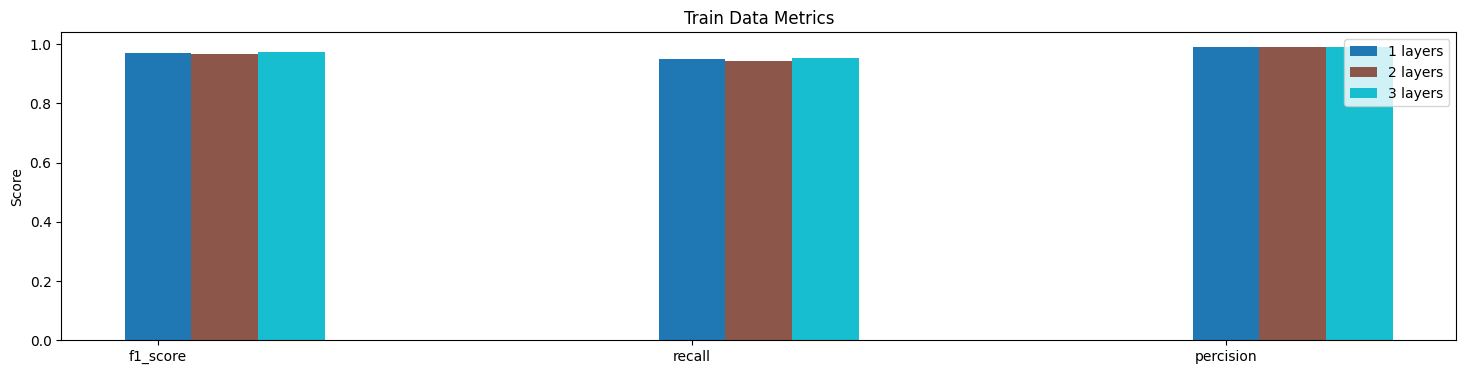

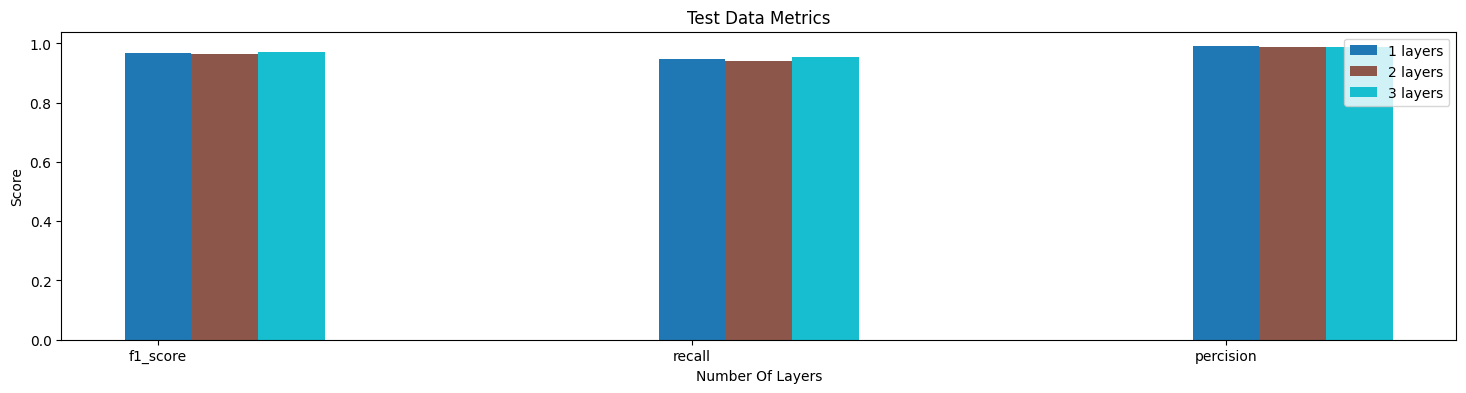

In [8]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
num_samples = X_train.shape[0]
layers_scheme = [[20], [20,10], [20,10,5]]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, layers in enumerate(layers_scheme):

    model = MLPClassifier(solver='adam',learning_rate="constant", learning_rate_init=0.01, alpha=1e-5,hidden_layer_sizes=layers,max_iter=500)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "layers": layers,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "layers": layers,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"{len(list(entry["layers"]))} layers" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"{len(list(entry["layers"]))} layers" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.xlabel("Number Of Layers")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### As it is obvious in the charts, the depth of the model does not affect the metrics. This indicates that the relationship between the features is probably not too non-linear.

#### Next width

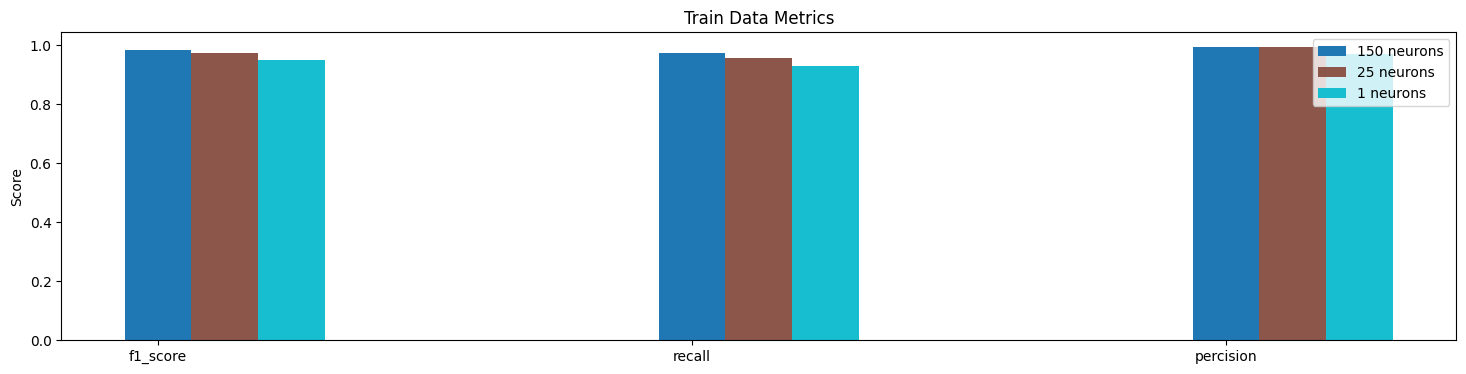

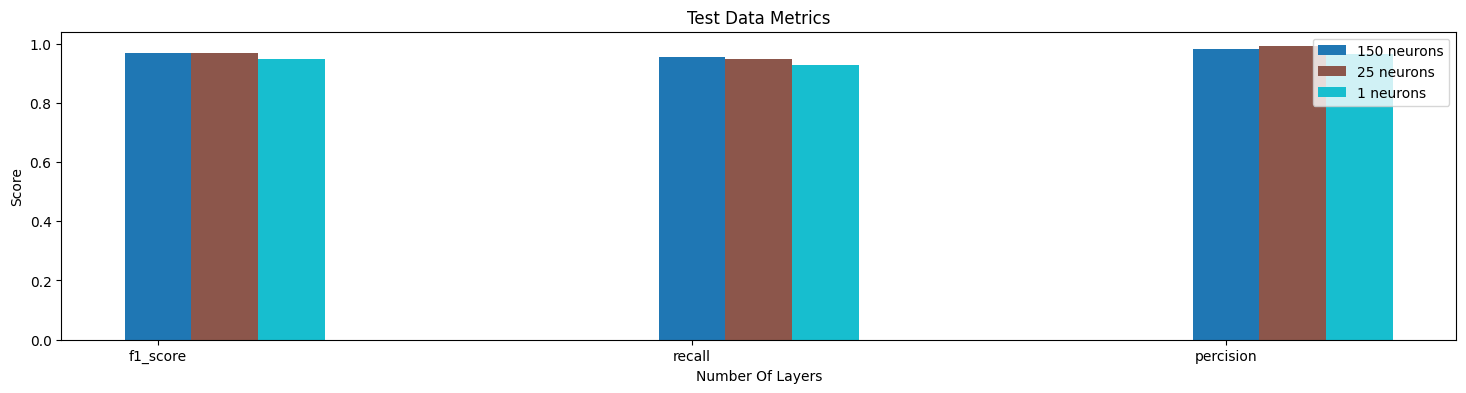

In [12]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
num_samples = X_train.shape[0]
widths = [150, 25, 1]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, w in enumerate(widths):

    model = MLPClassifier(solver='adam',learning_rate="constant", learning_rate_init=0.01, alpha=1e-5,hidden_layer_sizes=(w),max_iter=500)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "width": w,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "width": w,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"{entry["width"]} neurons" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f"{entry["width"]} neurons" if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.xlabel("Number Of Layers")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### These results indicate that there are only a handful of features that actually matter in the classification problem.

#### Now on to Activation Function

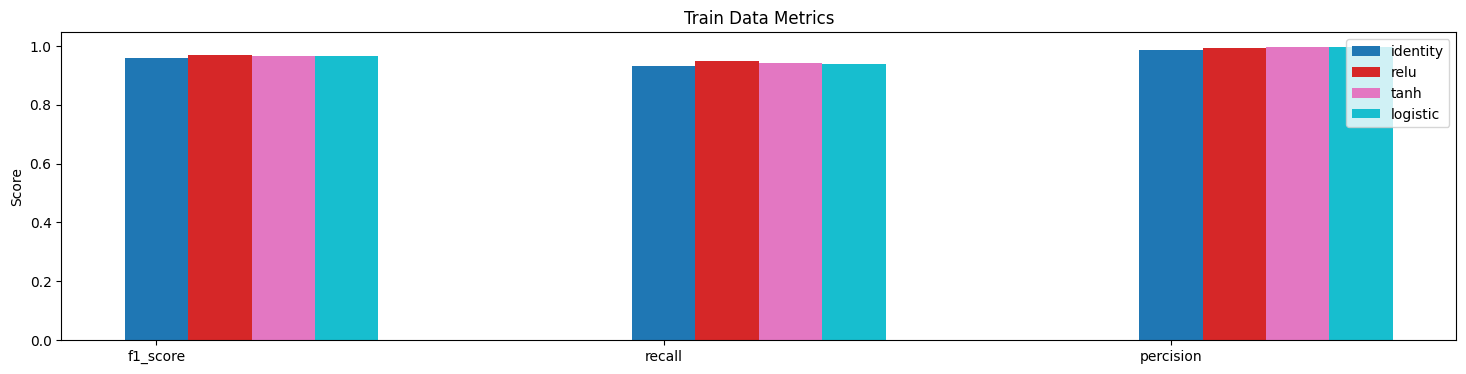

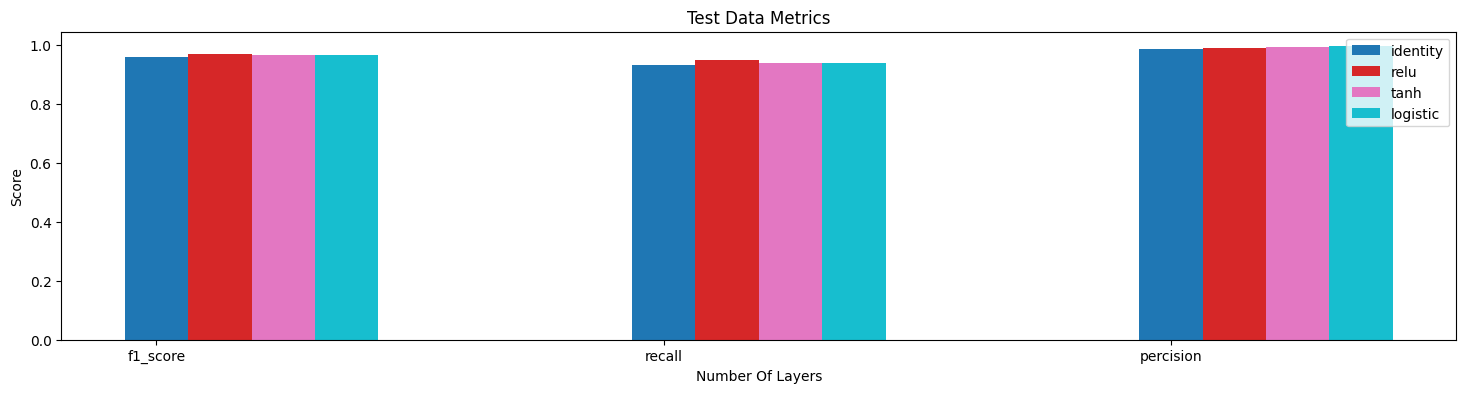

In [ ]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
num_samples = X_train.shape[0]
activations = ["identity", "relu", "tanh", "logistic"]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, act in enumerate(activations):

    model = MLPClassifier(solver='adam',activation=act,learning_rate="constant", learning_rate_init=0.01, alpha=1e-5,hidden_layer_sizes=(5,2),max_iter=500)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "activation": act,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "activation": act,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["activation"] if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["activation"] if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### The indifference between different activation functions most likely indicates that there aren't edge cases in the data.

### 1.1.B.3 Regularization & Stability

#### Now we examine the effect of regularization

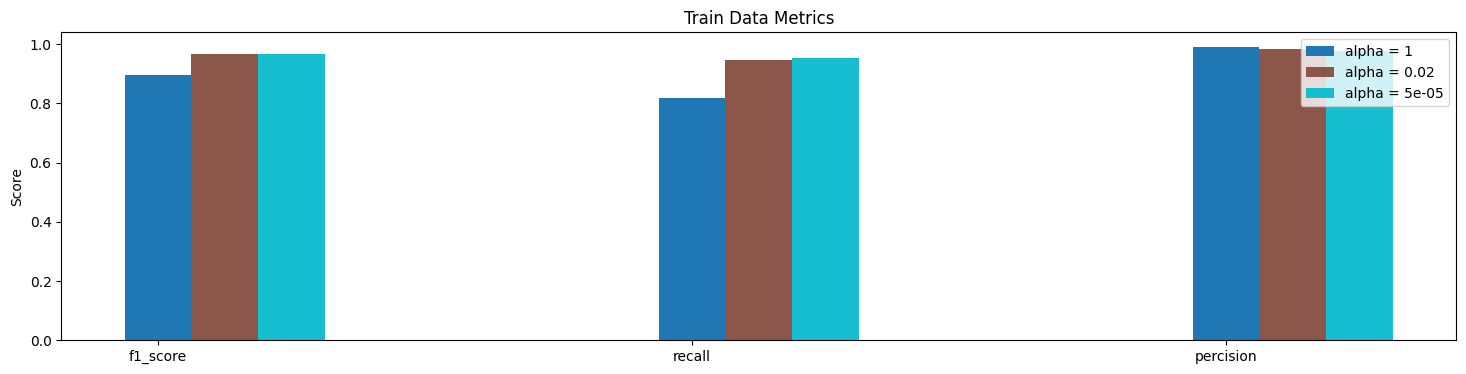

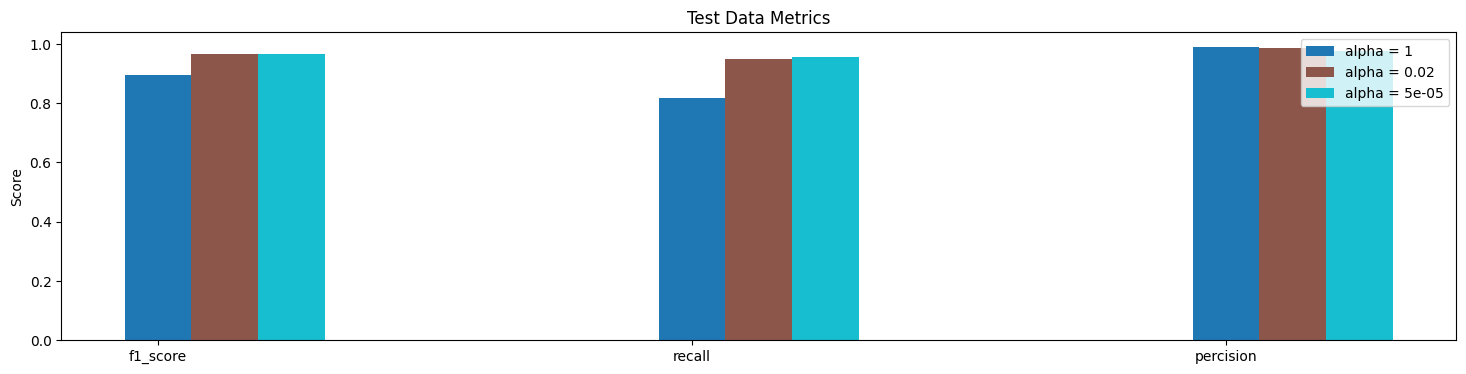

In [63]:
# Prepring data set
mlp_df = df.copy(True)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = [1, 2e-2, 5e-5]
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Solving for each solver
for i, option in enumerate(options):

    model = MLPClassifier(solver='adam',
                          learning_rate="constant", 
                          learning_rate_init=0.01, 
                          alpha=option, 
                          hidden_layer_sizes=(5,2),
                          max_iter=500)    
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    f1_train = f1_score(y_train,predictions_train)
    f1_test = f1_score(y_test,predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "option": option,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
        })
    
    results["test"].append({
        "option": option,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# Comparing different solvers for train data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f'alpha = {entry["option"]}' if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

# Comparing different solvers for test data
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f'alpha = {entry["option"]}' if i == 0 else ""  # avoid duplicate legend entries
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### We see that less regularization can reduce performance.

#### Now we examine the effect of activity regularization

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


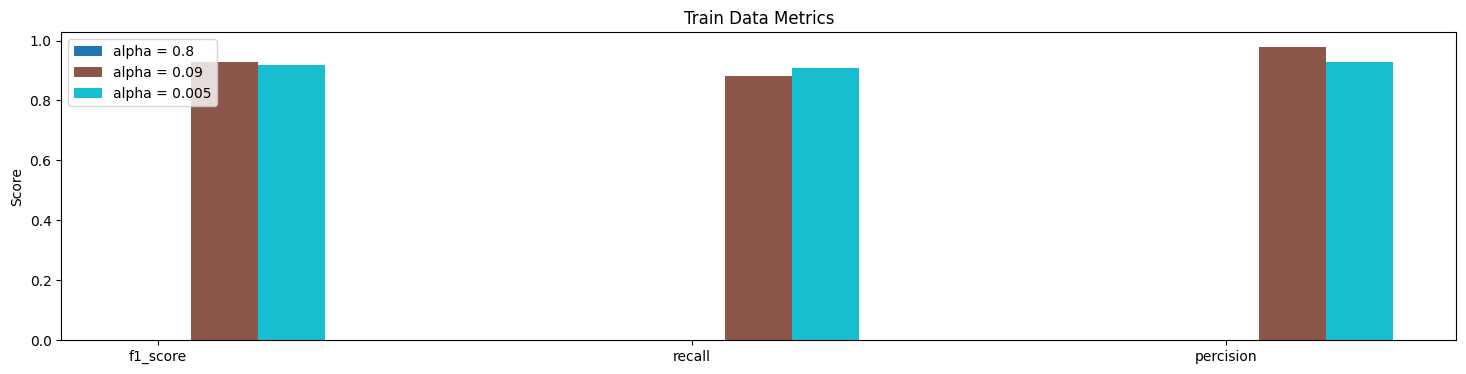

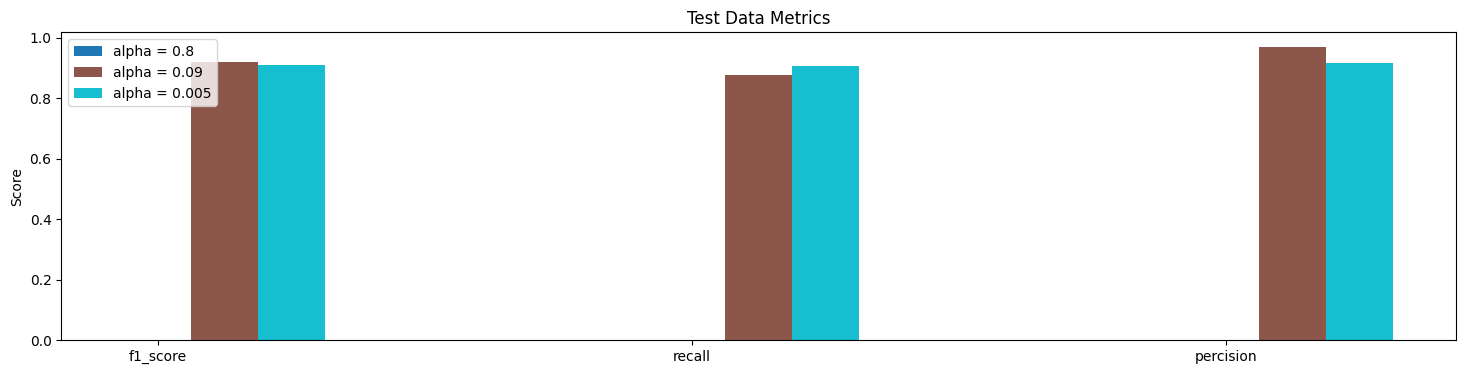

In [6]:
# Prepring data set
mlp_df = df.copy(True)
mlp_df = mlp_df.sample(n=10000)
cancels = mlp_df.pop("Canceled")
no_shows = mlp_df.pop("No-Show")
check_out = mlp_df.pop('Check-Out')

# Extracting train and test data
X_train, X_test, y_train, y_test = train_test_split(mlp_df,cancels,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = [0.8, 0.09, 0.005]   # now used as activity regularization strength
metrics = ["f1_score","recall","percision"]
results = {
    "train": [],
    "test": []
}

# Loop over activity regularization strengths
for i, option in enumerate(options):

    # Build model (same architecture as before: (5,2))
    model = Sequential([
        Dense(5, activation='relu',
              activity_regularizer=regularizers.l2(option),
              input_shape=(X_train.shape[1],)),
        Dense(2, activation='relu',
              activity_regularizer=regularizers.l2(option)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='binary_crossentropy'
    )

    # Train
    model.fit(X_train, y_train, epochs=50, verbose=0)

    # Predictions (convert probabilities → 0/1 like sklearn)
    predictions_train = (model.predict(X_train) > 0.5).astype(int).flatten()
    predictions_test = (model.predict(X_test) > 0.5).astype(int).flatten()

    # Metrics
    f1_train = f1_score(y_train, predictions_train)
    f1_test = f1_score(y_test, predictions_test)

    percision_train = precision_score(y_train, predictions_train)
    percision_test = precision_score(y_test, predictions_test)

    recall_train = recall_score(y_train, predictions_train)
    recall_test = recall_score(y_test, predictions_test)

    results["train"].append({
        "option": option,
        "f1_score": f1_train,
        "percision": percision_train,
        "recall": recall_train
    })
    
    results["test"].append({
        "option": option,
        "f1_score": f1_test,
        "percision": percision_test,
        "recall": recall_test
    })


# --- plotting section remains EXACTLY the same ---
plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))

for j, entry in enumerate(results["train"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f'alpha = {entry["option"]}' if i == 0 else ""
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Train Data Metrics")
plt.legend()

plt.figure(figsize=(18,4))
step = 0.8
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))

for j, entry in enumerate(results["test"]):
    for i, metric in enumerate(metrics):
        plt.bar(
            i * step + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=f'alpha = {entry["option"]}' if i == 0 else ""
        )

plt.xticks(np.arange(len(metrics)) * step, metrics)
plt.ylabel("Score")
plt.title("Test Data Metrics")
plt.legend()

plt.show()

#### We see that just activity regularization behaves like L2 regularization

### MLP For Regression
#### We need a continuous target like average daily rate

#### First we examine the effect of solver

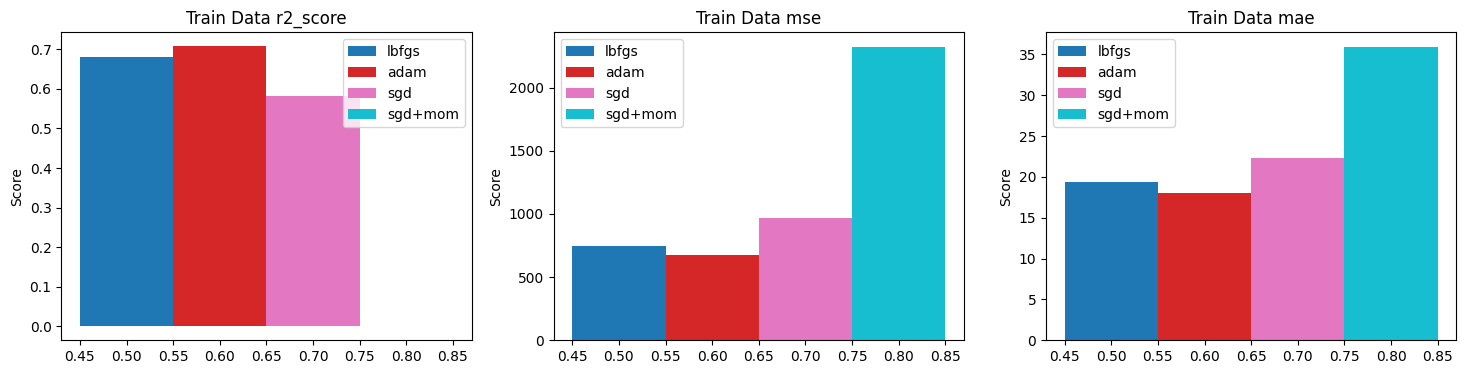

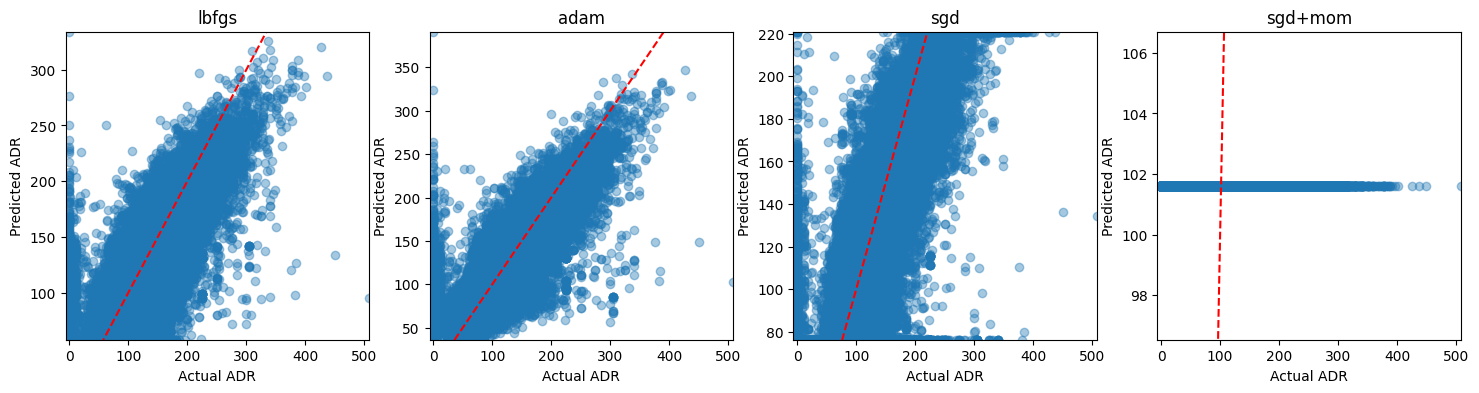

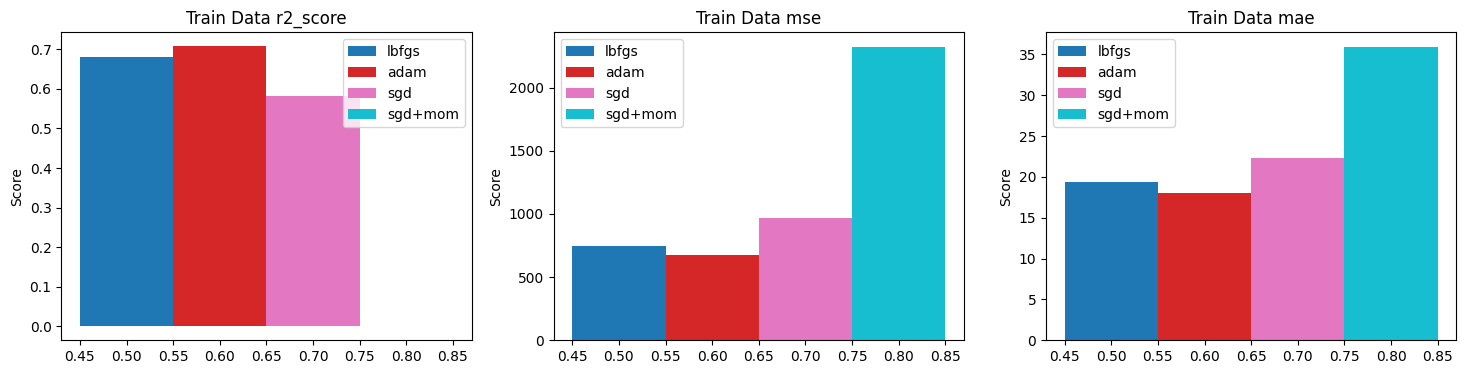

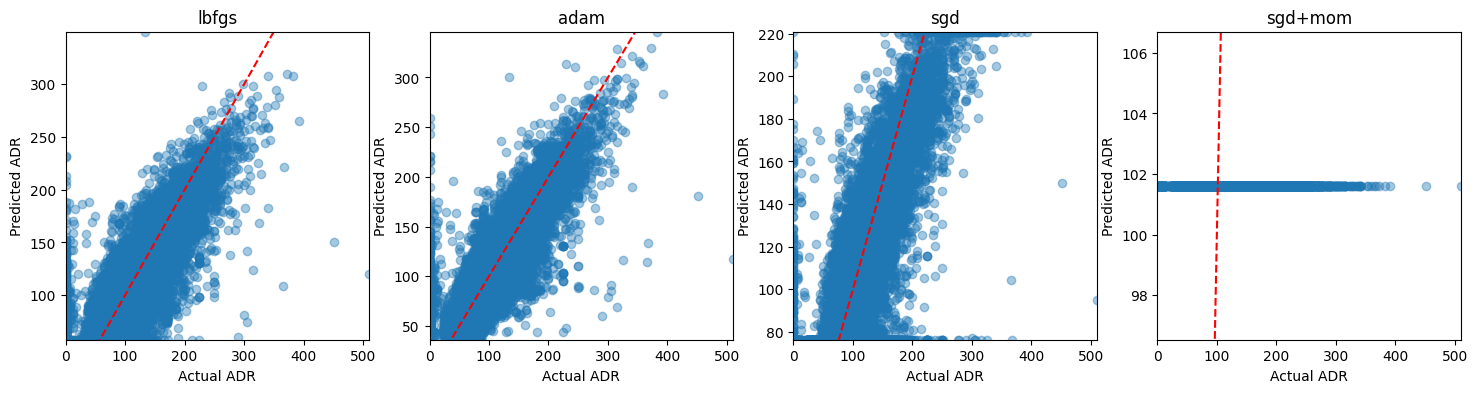

In [2]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.20)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = ["lbfgs", "adam", "sgd", "sgd+mom"]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    if option == "sgd+mom":
        model = MLPRegressor(solver='sgd', alpha=5e-5,hidden_layer_sizes=(5, 2),max_iter=500,momentum=.9)
    else:
        model = MLPRegressor(solver=option, alpha=5e-5,hidden_layer_sizes=(5, 2),max_iter=500)
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(entry["option"])

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(entry["option"])

plt.show()

#### We see that different solvers have approximately the same results. Also notice the sgd could be break, and act no better than a simple average.

#### Now we examine the effect of different learning rates.

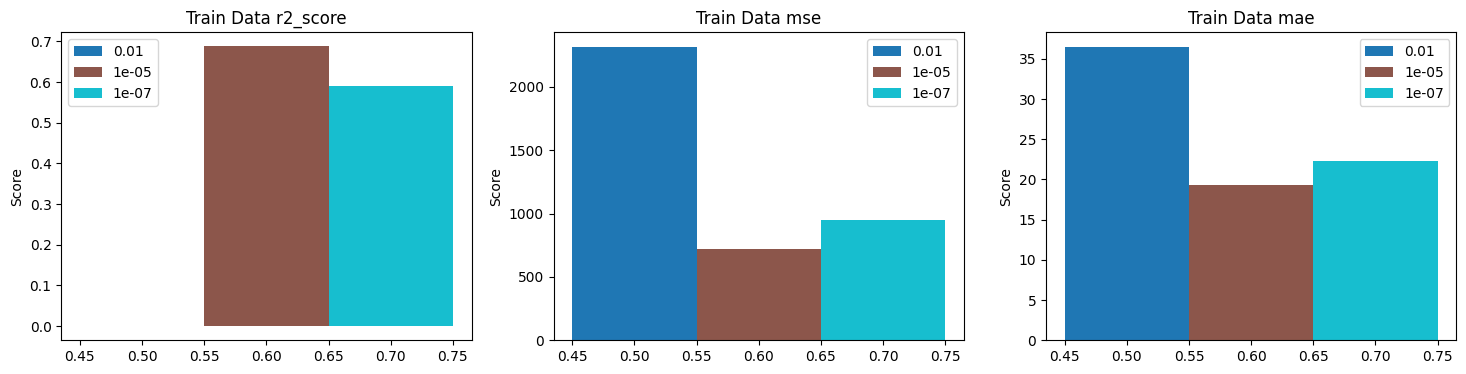

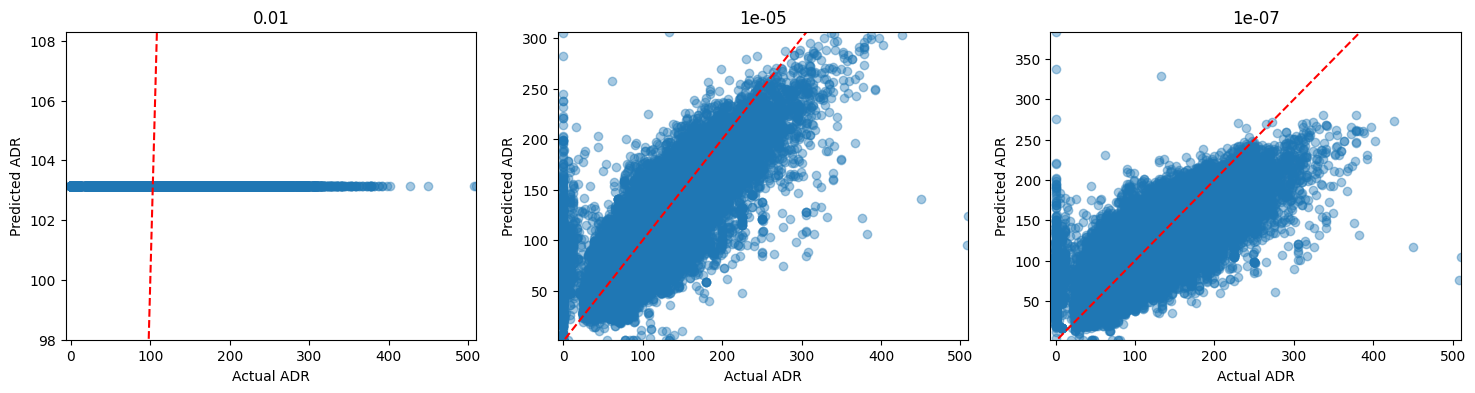

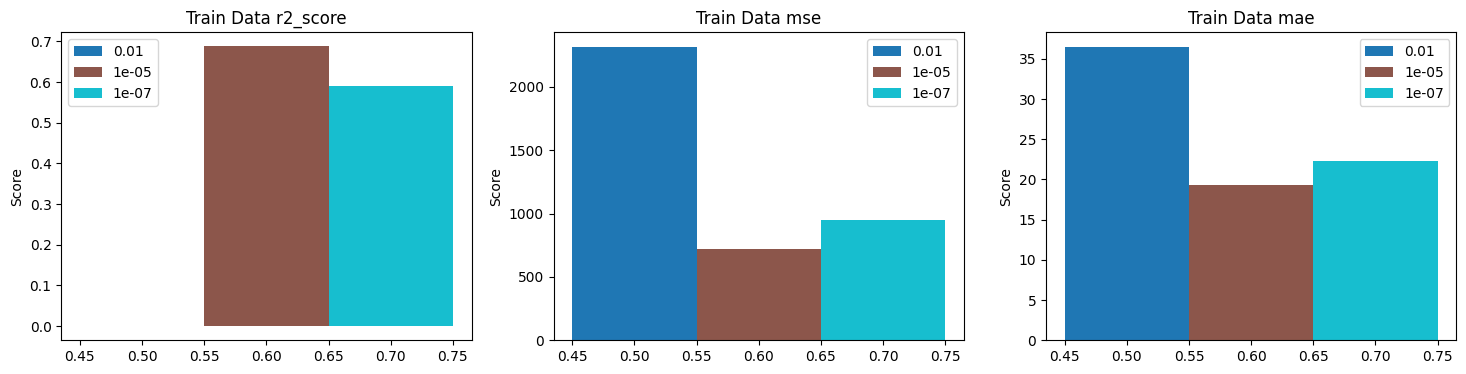

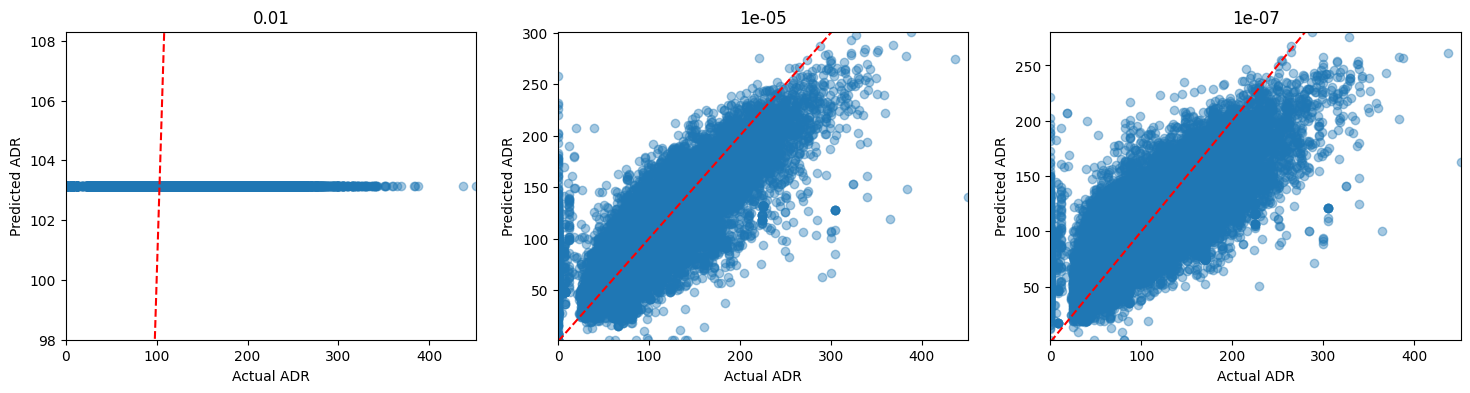

In [18]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = [0.01, 1e-5, 1e-7]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd", alpha=5e-5,hidden_layer_sizes=(5, 2),max_iter=500, learning_rate="constant", learning_rate_init=option)
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(entry["option"])

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(entry["option"])

plt.show()

#### We see that the optimal point, is inside a rather narrow cliff and large rates can miss the optimum point. Also, very small rates might not be able to reach the optimum point

#### Now we examine the effect of learning schedules.

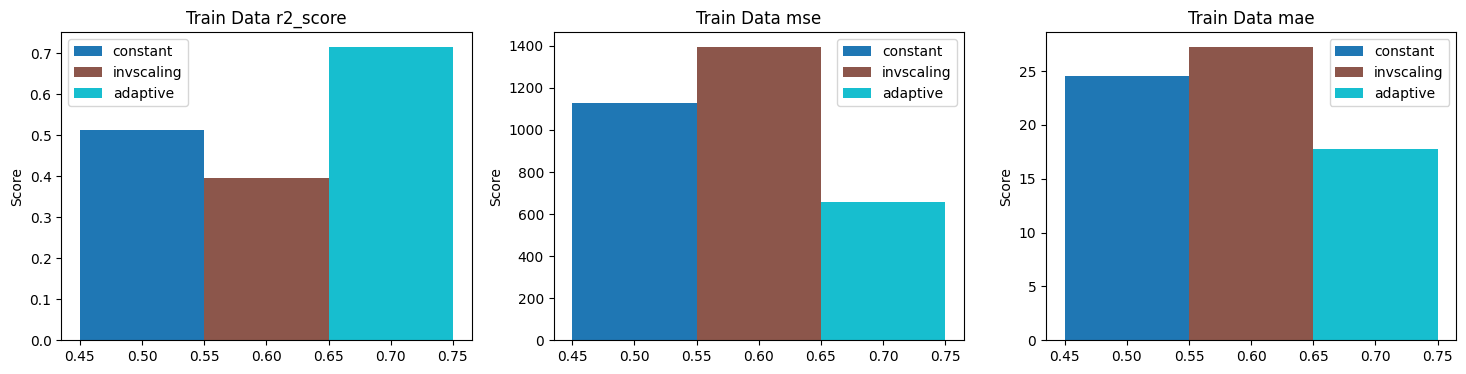

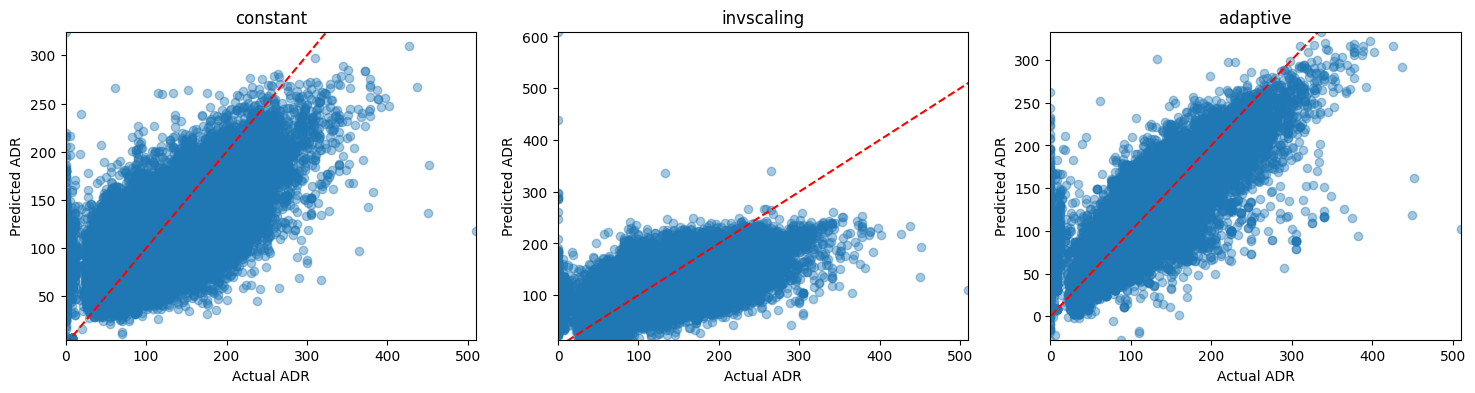

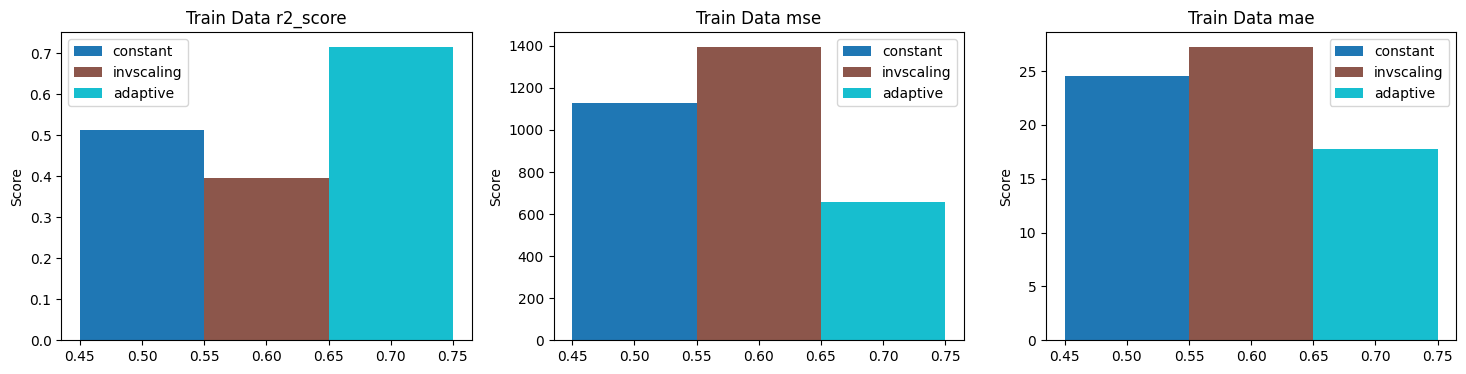

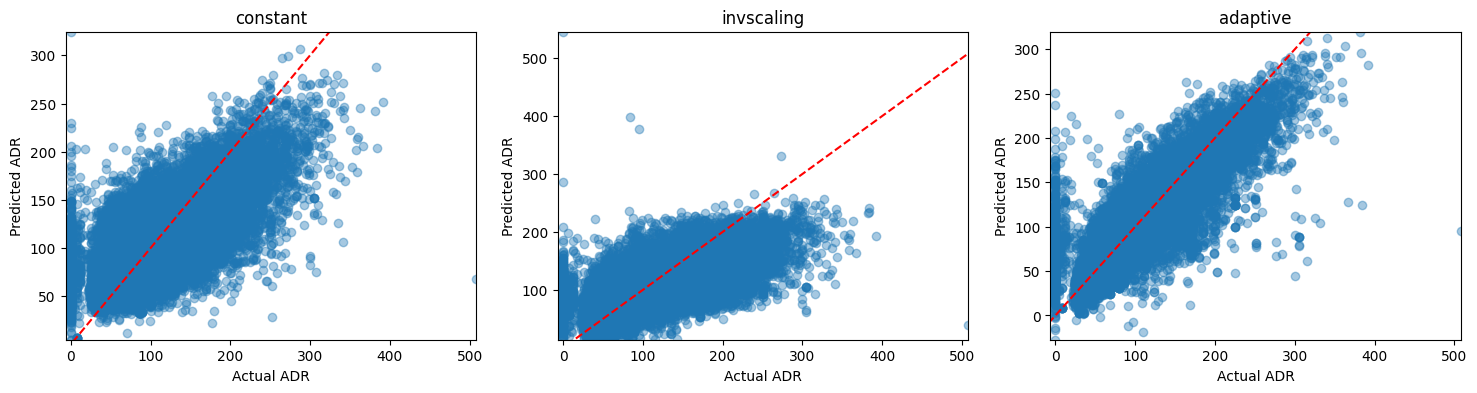

In [11]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = ["constant","invscaling","adaptive"]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd", alpha=5e-5,hidden_layer_sizes=(5, 2),max_iter=500, learning_rate=option, learning_rate_init=1e-5)
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(entry["option"])

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(entry["option"])

plt.show()

####

#### Now we examine the effect of batch size

In [ ]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
num_samples = X_train.shape[0]
options = [int(0.1*num_samples),int(0.02*num_samples),int(0.003*num_samples)]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd",
                        alpha=5e-5,
                        hidden_layer_sizes=(5, 2),
                        max_iter=500, 
                        learning_rate="adaptive", 
                        learning_rate_init=1e-5,
                        batch_size=option
                        )
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"size = {entry['option']}")

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"size = {entry['option']}")

plt.show()

####

#### Now we examine the effect of early stopping

In [ ]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = [10, 200, 450],
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd",
                        alpha=5e-5,
                        hidden_layer_sizes=(5, 2),
                        max_iter=500, 
                        learning_rate="adptive", 
                        learning_rate_init=1e-5,
                        early_stopping=True,
                        validation_fraction=0.1,
                        n_iter_no_change=option
                        )
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"iterations = {entry['option']}")

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"iterations = {entry['option']}")

plt.show()

####

#### Now we examine the effect of epochs number.

In [ ]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
epochs = [80,350,700]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd",
                        alpha=5e-5,
                        hidden_layer_sizes=(5, 2),
                        max_iter=options, 
                        learning_rate="adaptive", 
                        learning_rate_init=1e-5,
                        )
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"epoch = {entry['option']}")

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"epoch = {entry['option']}")

plt.show()

####

### 1.2.B.2 Architecture & Representation

#### Now we examine the effect of depth

In [ ]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = [(10),(10,5),(10,5,2)]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd",
                        alpha=5e-5,
                        hidden_layer_sizes=option,
                        max_iter=500, 
                        learning_rate="adaptive", 
                        learning_rate_init=1e-5,
                        )
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"epoch = {entry["option"]}")

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"epoch = {entry["option"]}")

plt.show()

####

#### Now we examine the effect of width

In [ ]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = [50,20,2]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd",
                        alpha=5e-5,
                        hidden_layer_sizes=[option],
                        max_iter=500, 
                        learning_rate="adaptive", 
                        learning_rate_init=1e-2,
                        )
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"width = {entry["option"]}")

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"width = {entry["option"]}")

plt.show()

####

#### Now we examine the effect of activation function

In [ ]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = ["relu","sigmoid","tanh", "identity"]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd",
                        alpha=5e-5,
                        hidden_layer_sizes=(5,2),
                        max_iter=500, 
                        learning_rate="adaptive", 
                        learning_rate_init=1e-2,
                        activation=option
                        )
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(entry["option"])

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(entry["option"])

plt.show()

### 1.2.B.3 Regulrization & Stability

#### Now we examine the effect of regularization.

In [ ]:
mlp_df = df.copy(True)
adr = mlp_df.pop("adr")
X_train, X_test, y_train, y_test = train_test_split(mlp_df,adr,test_size=0.35)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buffers
options = [1,2e-2,5e-5]
metrics = ["r2_score","mse","mae"]
results = {
    "train": [],
    "test": []
}

for i, option in enumerate(options):

    model = MLPRegressor(solver="sgd",
                        alpha=option,
                        hidden_layer_sizes=(5,2),
                        max_iter=500, 
                        learning_rate="adaptive", 
                        learning_rate_init=1e-2,
                        )
    model.fit(X_train, y_train)

    predictions_train = model.predict(X_train)
    predictions_test = model.predict(X_test)

    results["train"].append({
        "true": y_train,
        "prediction": predictions_train,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })

    results["test"].append({
        "true": y_test,
        "prediction": predictions_test,
        "option": option,
        "r2_score": r2_score(y_train, predictions_train),
        "mse": mean_squared_error(y_train, predictions_train),
        "mae": mean_absolute_error(y_test, predictions_test)
    })


plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["train"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["train"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()


plt.figure(figsize=(18,4))
for i, entry in enumerate(results["train"]):
    # Data points
    plt.subplot(1,len(results["train"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"alpha = {entry["option"]}")

plt.figure(figsize=(18,4))
start = 0.5
width = 0.1
colors = plt.cm.tab10(np.linspace(0, 1, len(results["test"])))
for i, metric in enumerate(metrics):
    plt.subplot(1,len(metrics),i+1)
    for j, entry in enumerate(results["test"]):
        plt.bar(
            start + j * width,
            entry[metric],
            width,
            color=colors[j],
            label=entry["option"]
        )
    plt.ylabel("Score")
    plt.title(f"Train Data {metric}")
    plt.legend()

plt.figure(figsize=(18,4))
for i, entry in enumerate(results["test"]):
    # Data points
    plt.subplot(1,len(results["test"]),i+1)
    plt.scatter(entry["true"], entry["prediction"], alpha=0.4)    
    # Perfect fit line
    min_val = min(entry["true"].min(), entry["prediction"].min())
    max_val = max(entry["true"].max(), entry["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.xlim((entry["true"].min(),entry["true"].max()))
    plt.ylim((entry["prediction"].min(),entry["prediction"].max()))
    plt.xlabel("Actual ADR")
    plt.ylabel("Predicted ADR")
    plt.title(f"alpha = {entry["option"]}")

plt.show()